# Average Treatment Effect & IV Nuance


**Question:** Does advertising work at all?

**Business decision:** This is the foundational sanity check of the whole case study. Before any targeting logic, we need the randomized answer to whether *assignment to advertising* raises visit / conversion probability at all, and by how much — this calibrates the ceiling for every downstream experiment.


**Outcomes:** `visit`, `conversion` (binary). `exposure` used only in the secondary IV analysis.

**Estimands:**
1. **ITT (primary, causal):** treated mean − control mean of each outcome. With randomization, difference-in-means is unbiased for the causal effect of *assignment to advertising* — not of actually seeing a banner (only ~3.6% of treated users were ever exposed).
2. **Wald IV (compliers-only: applies to the 3.6% exposed; requires the exclusion restriction; if exposure is defined partly by visit-like events the estimate is an upper bound) (secondary, suggestive):** effect of *exposure among the exposed* = ITT / P(exposure | treated), delta-method CI. An attempt to scale the diluted ITT up to the subset actually exposed.

**Assumptions:** randomization (verified) → ITT causal; row-level i.i.d. for the bootstrap. IV additionally needs: (a) exposure follows assignment — consistent with exposure among control being **exactly 0** (no defiers); (b) no noncompliance-driven confounding among the treated — NOT verifiable here; (c) exclusion restriction for the outcome itself is an idealization, so all IV numbers are labeled suggestive.

**Method:** pure two-arm proportion estimation + delta-method ratio. **No feature-based models** in this notebook.


In [1]:
import time
t0 = time.time()

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "src"))

import core
import viz

np.random.seed(42)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.5.3 | pandas 2.3.3


In [3]:
DF_PATH = ROOT / "data" / "criteo_uplift_v2_hashed.parquet"
df = pd.read_parquet(DF_PATH)

print(df.shape)
df.head()

(13979592, 17)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure,row_hash
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0,819569959
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0,4245558412
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0,2012869148
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0,834629253
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0,1064233312


## 1. Full-sample ITT effects on visit an conversion

Randomized assignment ⇒ the treated − control difference is a causal ITT effect. Given the sample size, we  compute **design-based and covariate-adjusted estimators** below and report agreement.

In [4]:
def wald_diff_ci(y, arm): #split outcome values in control and treatment groups, calculate sample sizes, event counts, proportions, effect size, standard error, and confidence intervals
    y0, y1 = y[arm == 0], y[arm == 1]
    n0, n1 = len(y0), len(y1)
    x0, x1 = int(y0.sum()), int(y1.sum())
    p0, p1 = x0 / n0, x1 / n1
    Z = 1.959
    eff = p1 - p0
    se = np.sqrt(p0 * (1 - p0) / n0 + p1 * (1 - p1) / n1)
    return dict(n_control=n0, n_treated=n1, ev_control=x0, ev_treated=x1,
                rate_control=p0, rate_treated=p1, eff_pp=100 * eff, se_pp=100 * se,
                wald_lo_pp=100 * (eff - Z * se), wald_hi_pp=100 * (eff + Z * se),
                rel_lift=eff / p0)

def binom_boot_ci(y, arm, B=5000, seed=42): #uses each arm's observed rate as its event probability, and simulates 5000 event counts per arm from a binomial, then calculates the treated - control rate diff for each sim; returns the 2.5th and 97.5 percentiles 
    rng = np.random.default_rng(seed)
    y0, y1 = y[arm == 0], y[arm == 1]
    n0, n1 = len(y0), len(y1)
    p0h, p1h = y0.mean(), y1.mean()
    s0 = rng.binomial(n0, p0h, B).astype(np.float64)
    s1 = rng.binomial(n1, p1h, B).astype(np.float64)
    boot = s1 / n1 - s0 / n0
    stat = float(y1.mean() - y0.mean())
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return dict(boot_lo_pp=100 * lo, boot_hi_pp=100 * hi, boot_se_pp=100 * float(boot.std()), boot_stat_pp=100 * stat)

ITT = {}
rows = []
for outcome in ["visit", "conversion"]:
    y, arm = df[outcome], df["treatment"]
    res = wald_diff_ci(y, arm)
    res.update(binom_boot_ci(y, arm, B=5000, seed=42))
    res["outcome"] = outcome
    ITT[outcome] = res
    rows.append(res)

df_ate = pd.DataFrame(rows)
df_ate = df_ate[["outcome", "n_control", "n_treated", "ev_control", "ev_treated",
                 "rate_control", "rate_treated", "eff_pp", "rel_lift", "se_pp",
                 "wald_lo_pp", "wald_hi_pp", "boot_lo_pp", "boot_hi_pp", "boot_se_pp"]]
df_ate["rate_control"] = df_ate["rate_control"].round(6)
df_ate["rate_treated"] = df_ate["rate_treated"].round(6)
df_ate["rel_lift"] = df_ate["rel_lift"].round(4)
df_ate.round(4).to_csv(ROOT / "outputs" / "tables" / "e3_ate.csv", index=False)
df_ate.round(4)

,outcome,n_control,n_treated,ev_control,ev_treated,rate_control,rate_treated,eff_pp,rel_lift,se_pp,wald_lo_pp,wald_hi_pp,boot_lo_pp,boot_hi_pp,boot_se_pp
0,visit,2096937,11882655,80105,576824,0.0382,0.0485,1.0342,0.2707,0.0146,1.0056,1.0629,1.0055,1.0633,0.0147
1,conversion,2096937,11882655,4063,36711,0.0019,0.0031,0.1152,0.5945,0.0034,0.1085,0.1219,0.1084,0.1219,0.0034


In [ ]:
for outcome in ["visit", "conversion"]:
    result = ITT[outcome]
    print(
        f"{outcome.title()}: control {100 * result['rate_control']:.4f}% "
        f"({result['ev_control']:,}/{result['n_control']:,}); "
        f"assigned to treatment {100 * result['rate_treated']:.4f}% "
        f"({result['ev_treated']:,}/{result['n_treated']:,})."
    )
    print(
        f"  Difference: {result['eff_pp']:+.4f} percentage points "
        f"(relative lift {100 * result['rel_lift']:+.1f}%)."
    )
    print(
        f"  95% CI: Wald [{result['wald_lo_pp']:+.4f}, {result['wald_hi_pp']:+.4f}] pp; "
        f"bootstrap [{result['boot_lo_pp']:+.4f}, {result['boot_hi_pp']:+.4f}] pp.\n"
    )

Visit: control 3.8201% (80,105/2,096,937); assigned to treatment 4.8543% (576,824/11,882,655).
  Difference: +1.0342 percentage points (relative lift +27.1%).
  95% CI: Wald [+1.0056, +1.0629] pp; bootstrap [+1.0055, +1.0633] pp.

Conversion: control 0.1938% (4,063/2,096,937); assigned to treatment 0.3089% (36,711/11,882,655).
  Difference: +0.1152 percentage points (relative lift +59.4%).
  95% CI: Wald [+0.1085, +0.1219] pp; bootstrap [+0.1084, +0.1219] pp.



In [7]:
df["fold"] = df["row_hash"] % 5
fold_rows = []

for outcome in ["visit", "conversion"]:
    pooled_effect = ITT[outcome]["eff_pp"]

    for fold_id, fold_data in df.groupby("fold", sort=True):
        fold_result = wald_diff_ci(fold_data[outcome], fold_data["treatment"])
        pooled_effect_in_ci = (
            fold_result["wald_lo_pp"] - 1e-12
            <= pooled_effect
            <= fold_result["wald_hi_pp"] + 1e-12
        )
        fold_rows.append({
            "outcome": outcome,
            "fold": int(fold_id),
            "n": len(fold_data),
            "eff_pp": fold_result["eff_pp"],
            "wald_lo_pp": fold_result["wald_lo_pp"],
            "wald_hi_pp": fold_result["wald_hi_pp"],
            "covers_pooled": pooled_effect_in_ci,
        })

df_folds = pd.DataFrame(fold_rows)
df_folds.round(4).to_csv(
    ROOT / "outputs" / "tables" / "e3_ate_folds.csv",
    index=False,
)
df_folds.round(4)

,outcome,fold,n,eff_pp,wald_lo_pp,wald_hi_pp,covers_pooled
0,visit,0,2796847,1.0160,0.9518,1.0802,True
1,visit,1,2798120,1.0445,0.9805,1.1086,True
2,visit,2,2795330,1.0537,0.9899,1.1175,True
3,visit,3,2793563,1.0458,0.9815,1.1101,True
4,visit,4,2795732,1.0113,0.9472,1.0755,True
5,conversion,0,2796847,0.1141,0.0989,0.1294,True
6,conversion,1,2798120,0.1144,0.0994,0.1295,True
7,conversion,2,2795330,0.1102,0.0951,0.1253,True
8,conversion,3,2793563,0.1179,0.1029,0.1329,True
9,conversion,4,2795732,0.1192,0.1043,0.1341,True


In [8]:
## Descriptive consistency check: how many fold-level 95% CIs cover the pooled estimate?
for outcome, outcome_folds in df_folds.groupby("outcome", sort=False):
    pooled_ci_count = int(outcome_folds["covers_pooled"].sum())
    fold_count = len(outcome_folds)
    effect_min = outcome_folds["eff_pp"].min()
    effect_max = outcome_folds["eff_pp"].max()

    print(
        f"{outcome.title()}: the pooled estimate falls within "
        f"{pooled_ci_count} of {fold_count} fold-level 95% confidence intervals. "
        f"Fold estimates range from {effect_min:+.4f} to {effect_max:+.4f} pp."
    )



Visit: the pooled estimate falls within 5 of 5 fold-level 95% confidence intervals. Fold estimates range from +1.0113 to +1.0537 pp.
Conversion: the pooled estimate falls within 5 of 5 fold-level 95% confidence intervals. Fold estimates range from +0.1102 to +0.1192 pp.


## 3. Figures

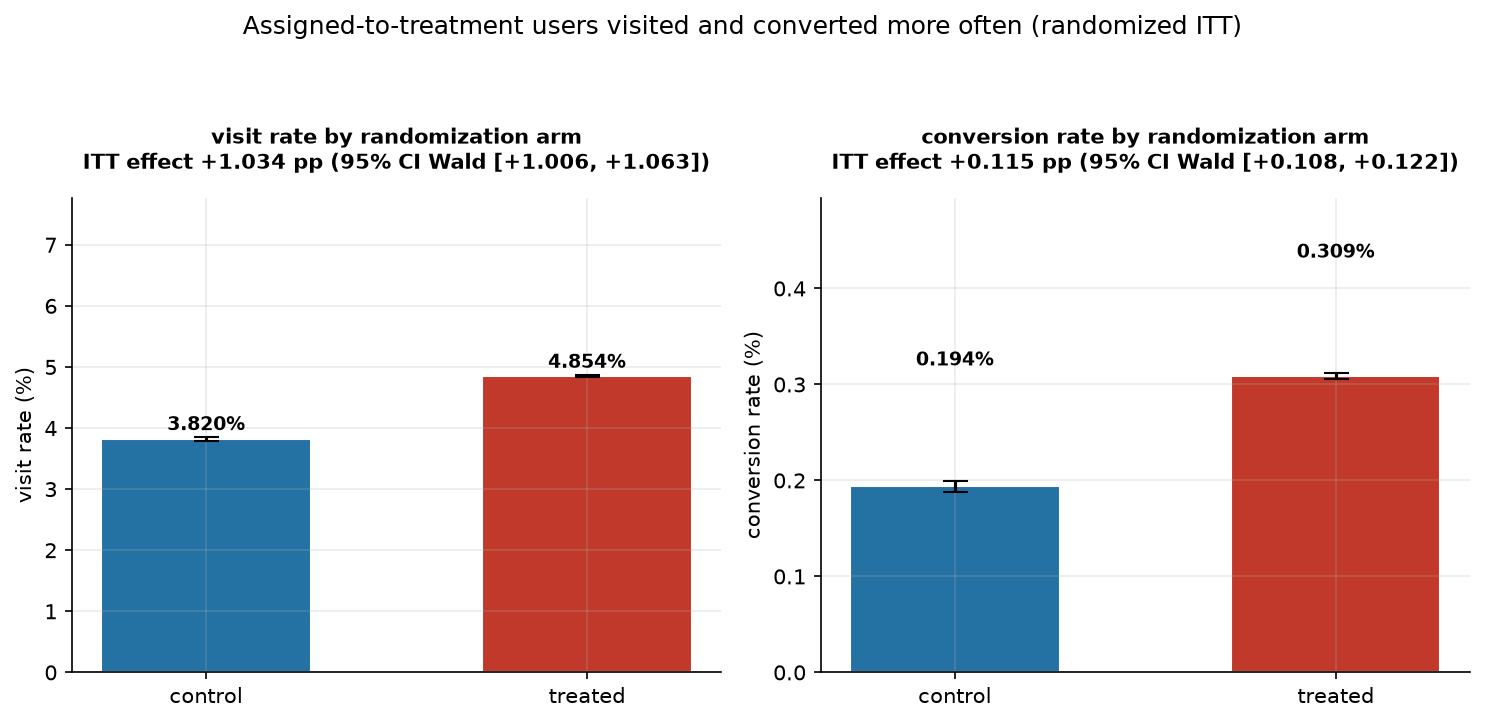

saved


In [ ]:
def wilson(x, n, Z=1.959963984540054): #Calculating a 95% Wilson confidence interval for a group outcome rate
    p = x / n
    d = 1 + Z * Z / n
    c = (p + Z * Z / (2 * n)) / d
    h = Z * np.sqrt(p * (1 - p) / n + Z * Z / (4 * n * n)) / d
    return np.array([c - h, c + h])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=False)
for ax, o in zip(axes, ["visit", "conversion"]): #for each group observed outcome, get the ITT results and plot the control and treated rates with error bars representing the Wilson confidence intervals
    r = ITT[o]
    rates = [100 * r["rate_control"], 100 * r["rate_treated"]]
    n = [r["n_control"], r["n_treated"]]
    ev = [r["ev_control"], r["ev_treated"]]
    cis = [100 * wilson(ev[i], n[i]) for i in range(2)]
    err = [[rates[i] - cis[i][0], cis[i][1] - rates[i]] for i in range(2)]
    bars = ax.bar(["control", "treated"], rates, yerr=np.array(err).T, capsize=6,
                  color=["#2471a3", "#c0392b"], edgecolor="white", width=0.55)
    ax.set_title(f"{o} rate by randomization arm\nITT effect {r['eff_pp']:+.3f} pp "
                 f"(95% CI Wald [{r['wald_lo_pp']:+.3f}, {r['wald_hi_pp']:+.3f}])", fontsize=10, pad=14)
    for xi, b in enumerate(bars):
        ax.text(b.get_x() + b.get_width() / 2, cis[xi][1] + 0.12, f"{rates[xi]:.3f}%",
                ha="center", fontsize=9, fontweight="bold")
    ax.set_ylabel(f"{o} rate (%)")
    ax.set_ylim(0, max(rates) * 1.6)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Assigned-to-treatment users visited and converted more often (randomized ITT)", fontsize=12, y=1.06)
fig.tight_layout()
plt.show()
viz.savefig(fig, "e3_ate_outcomes_by_arm")
print("saved")

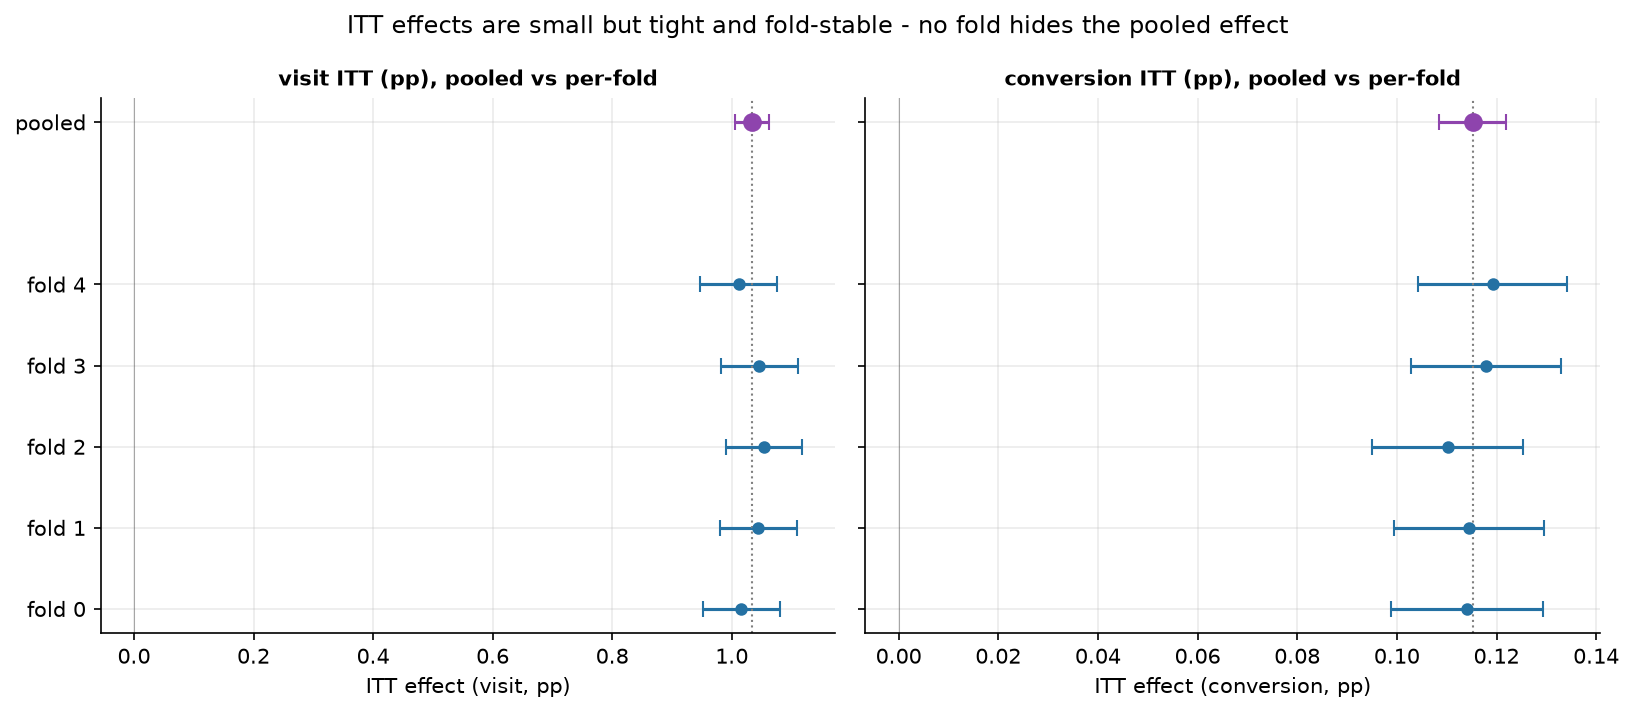

figure saved


In [13]:
## Forest style figure, pooled and per fold ITT effects
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
for ax, o in zip(axes, ["visit", "conversion"]):
    pooled = ITT[o]
    sub = df_folds[df_folds.outcome == o].sort_values("fold")
    ys, xs, los, his, cols, labels = [], [], [], [], [], []
    ys.append(len(sub) + 1)
    xs.append(pooled["eff_pp"]); los.append(pooled["wald_lo_pp"]); his.append(pooled["wald_hi_pp"])
    cols.append("#8e44ad"); labels.append("pooled")
    for _, rr in sub.iterrows():
        ys.append(int(rr.fold))
        xs.append(rr.eff_pp); los.append(rr.wald_lo_pp); his.append(rr.wald_hi_pp)
        cols.append("#2471a3"); labels.append(f"fold {int(rr.fold)}")
    order = np.argsort(ys)[::-1]
    ys = [ys[i] for i in order]; xs = [xs[i] for i in order]
    los = [los[i] for i in order]; his = [his[i] for i in order]
    cols = [cols[i] for i in order]; labels = [labels[i] for i in order]
    for yy, xx, ll, hh, cc, lb in zip(ys, xs, los, his, cols, labels):
        ax.errorbar(xx, yy, xerr=[[xx - ll], [hh - xx]], fmt="o", color=cc, capsize=4,
                    markersize=8 if lb == "pooled" else 5)
    ax.axvline(pooled["eff_pp"], color="gray", ls=":", lw=1)
    ax.set_yticks(ys)
    ax.set_yticklabels(labels)
    ax.set_xlabel(f"ITT effect ({o}, pp)")
    ax.axvline(0, color="k", lw=0.5, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(f"{o} ITT (pp), pooled vs per-fold", fontsize=10)
fig.suptitle("ITT effects are small but tight and fold-stable - no fold hides the pooled effect", fontsize=11.5)
fig.tight_layout()
plt.show()
viz.savefig(fig, "e3_ate_forest")
print("figure saved")



Each panel shows the estimated ITT effect for one outcome (visit and conversion), purple dot is the the full-sample estimate and its 95% Wald Confidence interval

Blue dots are per for each of the five hash-based fodls

Dotted vertical line: Pooled estimate, the thin gray line at zero marks that there's no difference between assignment groups

## 4. Exposure Nuance: Who sees the ad? and Wald IV Scaling

Exposure is only observable among the treated, two questions:
1) Who gerts exposed? Purely descriptive
2) Causal-scaled: Wald IV, effect of exposure among the exposed = ITT / uptake

We want to check the effect of exposure among the exposed, assuming monotonicity and no noncompliance-driven confounding

In [15]:
treated = df[df.treatment == 1]
uptake = float(treated.exposure.mean()) #calculate the mean exposure rate for treated users
assert float(df[df.treatment == 0].exposure.mean()) == 0.0, "control exposure must be exactly 0"
print(f"exposure rate | treated = {uptake:.6f}  | control = 0 (already verified)")
print(f"exposed treated users: {int(treated.exposure.sum()):,} of {len(treated):,}")

exposure rate | treated = 0.036037  | control = 0 (already verified)
exposed treated users: 428,212 of 11,882,655


In [19]:
# associational: exposure rate by outcome status and by f9 deciles (treated users only, n=11.9M)
by_visit = treated.groupby("visit").exposure.mean()
by_conv = treated.groupby("conversion").exposure.mean()

# f9 has a large mass at its floor value, so plain quantile cuts lump ~2/3 of rows into the "bottom decile".
# Use positional deciles on a stable sort instead: exactly 10% of treated rows per side, ties broken by row order.
ts = treated.sort_values("f9", kind="stable").reset_index(drop=True)
m = len(ts)
bottom, top = ts.iloc[: m // 10], ts.iloc[-(m // 10):]
dec = pd.DataFrame({
    "group": ["f9 bottom decile", "f9 top decile"],
    "n": [len(bottom), len(top)],
    "exposure_rate": [bottom.exposure.mean(), top.exposure.mean()],
    "visit_rate": [bottom.visit.mean(), top.visit.mean()],
    "conversion_rate": [bottom.conversion.mean(), top.conversion.mean()],
})

exposure_assoc = pd.DataFrame({
    "segment": ["visit=0", "visit=1", "conversion=0", "conversion=1", "f9 bottom decile", "f9 top decile"],
    "exposure_rate": [by_visit[0], by_visit[1], by_conv[0], by_conv[1],
                      dec.iloc[0].exposure_rate, dec.iloc[1].exposure_rate],
    "n": [int((treated.visit == 0).sum()), int((treated.visit == 1).sum()),
          int((treated.conversion == 0).sum()), int((treated.conversion == 1).sum()),
          len(bottom), len(top)],
})
exposure_assoc["exposure_rate"] = exposure_assoc["exposure_rate"].round(6)
exposure_assoc

,segment,exposure_rate,n
0,visit=0,0.022175,11305831
1,visit=1,0.307737,576824
2,conversion=0,0.034204,11845944
3,conversion=1,0.627360,36711
4,f9 bottom decile,0.012754,1188265
5,f9 top decile,0.149715,1188265


In [17]:
ivrows = []
for o in ["visit", "conversion"]:
    r = ITT[o]
    itt, se = r["eff_pp"], r["se_pp"]
    iv = itt / uptake
    se_iv = se / uptake
    Z = 1.959963984540054
    ivrows.append(dict(outcome=o, itt_pp=itt, uptake=uptake, iv_pp=iv,
                       iv_lo_pp=iv - Z * se_iv, iv_hi_pp=iv + Z * se_iv,
                       itt_lo_pp=r["wald_lo_pp"], itt_hi_pp=r["wald_hi_pp"]))
df_iv = pd.DataFrame(ivrows)
df_iv.round(4).to_csv(ROOT / "outputs" / "tables" / "e3_exposure_iv.csv", index=False)
df_iv.round(4)

,outcome,itt_pp,uptake,iv_pp,iv_lo_pp,iv_hi_pp,itt_lo_pp,itt_hi_pp
0,visit,1.0342,0.036,28.6996,27.9038,29.4954,1.0056,1.0629
1,conversion,0.1152,0.036,3.1964,3.0094,3.3833,0.1085,0.1219


## Caveat confirmed by Criteo

The Criteo Uplift v2 organizers documented **non-uniform subsampling**: zero-visit rows are heavily downsampled, so the *absolute* visit/conversion rates and the absolute ITT magnitudes above are **not** representative of any real production traffic.  What survives: the *randomized design* (so within-benchmark ITT contrasts remain internally valid), **relative** comparisons (e.g. treated vs control, across folds, across models in later experiments), and **scale-free shares**. Absolute effect sizes should always be presented with this caveat attached, and sections above were written with it in mind.

## Adjustment Diagnostic: Small imbalance

1. **Treatment predictability** (cross-fitted HistGB propensity, halves defined by row_hash parity, 2M-row training sample per half): AUC ≈ 0.51 → features barely predict assignment.
2. **Design-based Horvitz–Thompson** with the known constant e = 0.85: algebraically identical to the raw difference in means at this design (reported for transparency).
3. **Covariate-adjusted ATE**: fully-interacted OLS (Lin 2013, z-scored features) + learned-e IPW (clipped [0.01, 0.99]).

duplicated near-clone rows shrink the effective sample (naive SEs understate the true uncertainty of the adjusted–raw gap); the adjusted estimators target the covariate-stratified ATE, the raw difference the design-weighted one.

In [22]:
import time
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

t0 = time.time()

#use the 12 pre-treatment features to check assignment balance and adjust visit estimate
FEATS = [f"f{i}" for i in range(12)]
X = df[FEATS].to_numpy(np.float32)
t_arr = df.treatment.to_numpy()
y_arr = df.visit.to_numpy()

# Split by a stable hash so each half can be predicted using a model trained on the other half
half = (df["row_hash"] % 2).to_numpy()
rng = np.random.default_rng(42)
e = np.empty(len(df)); pred_aucs = []
for k in (0, 1):
    other = np.flatnonzero(half != k); here = np.flatnonzero(half == k)
    tr = rng.choice(other, 2_000_000, replace=False)

    #Fit on a 2M-row sample from the opposite half, then predict in this half
    sc = rng.choice(here, 2_000_000, replace=False)
    m = HistGradientBoostingClassifier(max_iter=100, random_state=42).fit(X[tr], t_arr[tr])
    e[here] = m.predict_proba(X[here])[:, 1]

    # AUC near 0.5 means these features provide little predictive information about treatment assignment, which is good for balance and overlap
    pred_aucs.append(roc_auc_score(t_arr[sc], e[sc]))


#Keep the predicted probabilities within a reasonable range to avoid extreme weights in the IPW estimator
e = np.clip(e, 0.01, 0.99)

#Inverse probability weighting (IPW) estimator for the average treatment effect (ATE)
ipw_ate = np.mean(y_arr * t_arr / e - y_arr * (1 - t_arr) / (1 - e))
Xd = df[FEATS].to_numpy(np.float64)

#Standardize
Xz = (Xd - Xd.mean(0)) / Xd.std(0)

#Fully interact treatment with the features, then fit a linear regression to estimate the ATE while adjusting for the features. This is equivalent to the Lin (2013) estimator.
D = np.column_stack([np.ones(len(df)), Xz, t_arr.astype(float), Xz * t_arr.astype(float)[:, None]])

#Accumulate least-squares cross-products in chunks
A = np.zeros((26, 26))
b = np.zeros(26)
Bc = 2_000_000
n = len(df)
y64 = y_arr.astype(np.float64)


for s in range(0, n, Bc):
    d = D[s:s+Bc]; A += d.T @ d; b += d.T @ y64[s:s+Bc]

# Solve OLS normal equation; coefficient 13 is the treatment term after the intercept and 12 pre-treatment features, which is the Lin (2013) ATE estimate
beta_lin = np.linalg.solve(A, b)
lin_ate = beta_lin[13]

# Compare the raw randomized contrast, the known-e IPW, the learned-e IPW, and the fully-interacted OLS (Lin 2013) estimates of the ATE in percentage points
adj_tab = pd.DataFrame([
    dict(estimator="raw diff-in-means (design-based)", ate_pp=round((y64[t_arr==1].mean()-y64[t_arr==0].mean())*100, 4)),
    dict(estimator="HT, known e=0.85 (== raw by identity)", ate_pp=round(np.mean(y64*t_arr/0.85 - y64*(1-t_arr)/0.15)*100, 4)),
    dict(estimator="learned-e IPW (clipped)", ate_pp=round(ipw_ate*100, 4)),
    dict(estimator="fully-interacted OLS (Lin 2013)", ate_pp=round(lin_ate*100, 4)),
])
adj_tab.to_csv(ROOT / "outputs" / "tables" / "e3_ate_adjustment_diagnostics.csv", index=False)
print("treatment-predictability AUC (halves):", [round(a, 4) for a in pred_aucs])
adj_tab

treatment-predictability AUC (halves): [0.5102, 0.5096]


,estimator,ate_pp
0,raw diff-in-means (design-based),1.0342
1,"HT, known e=0.85 (== raw by identity)",1.0342
2,learned-e IPW (clipped),0.7709
3,fully-interacted OLS (Lin 2013),0.7734
